In [1]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [2]:
# Load dataset
df = pd.read_csv("addimbalanced_dataset.csv")  # Your dataset path
df = df[['Review', 'Rating']]

print(df['Rating'].value_counts())

# Encode labels (Ratings)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Rating'])
num_labels = len(label_encoder.classes_)

# Split data
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Review'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

Rating
4.0    75000
3.0    62500
5.0    50000
2.0    37500
1.0    25000
Name: count, dtype: int64


Tokenize text and convert to sequences

In [3]:
max_vocab_size = 10000  # Adjust based on your dataset size
max_seq_len = 128       # Max review length (in tokens)

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

train_padded = pad_sequences(train_sequences, maxlen=max_seq_len, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_seq_len, padding='post', truncating='post')

Tensorflow dataset

In [4]:
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((train_padded, train_labels)).shuffle(1000).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((test_padded, test_labels)).batch(batch_size)

LSTM Model

In [5]:
embedding_dim = 128

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_len),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_labels, activation='softmax')
])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 128, 128)          1280000   
                                                                 
 bidirectional (Bidirectiona  (None, 128, 128)         98816     
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 5)                 3

Compile model

In [6]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

Class weights

In [7]:
import numpy as np
from sklearn.utils import class_weight

class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {i : class_weights_values[i] for i in range(num_labels)}
print("Class weights:", class_weights)

Class weights: {0: 2.0, 1: 1.3333333333333333, 2: 0.8, 3: 0.6666666666666666, 4: 1.0}


Train the model

In [8]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience=3,            # Stop if no improvement for 3 consecutive epochs
    restore_best_weights=True  # Roll back to best weights after stopping
)


In [9]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,           # Set a higher max epoch count
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
6250/6250 [==============================] - 405s 63ms/step - loss: 1.1417 - accuracy: 0.4712 - val_loss: 1.1157 - val_accuracy: 0.4938
Epoch 2/20
6250/6250 [==============================] - 391s 62ms/step - loss: 1.0478 - accuracy: 0.5144 - val_loss: 1.1197 - val_accuracy: 0.4935
Epoch 3/20
6250/6250 [==============================] - 391s 63ms/step - loss: 0.9955 - accuracy: 0.5387 - val_loss: 1.1071 - val_accuracy: 0.5045
Epoch 4/20
6250/6250 [==============================] - 393s 63ms/step - loss: 0.9442 - accuracy: 0.5615 - val_loss: 1.1484 - val_accuracy: 0.5003
Epoch 5/20
6250/6250 [==============================] - 388s 62ms/step - loss: 0.8913 - accuracy: 0.5867 - val_loss: 1.2255 - val_accuracy: 0.4936
Epoch 6/20
6250/6250 [==============================] - 390s 62ms/step - loss: 0.8386 - accuracy: 0.6104 - val_loss: 1.2990 - val_accuracy: 0.4891


In [10]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np


In [11]:
# Predict probabilities
y_pred_probs = model.predict(test_dataset)

# Convert probs to predicted class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels from test dataset
y_true = np.concatenate([y for x, y in test_dataset], axis=0)


1563/1563 [==============================] - 43s 26ms/step


In [12]:
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_true, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

print("Confusion Matrix:")
print(conf_matrix)


Test Accuracy: 0.5045
Test Precision: 0.5057
Test Recall: 0.5045
Test F1 Score: 0.4944
Confusion Matrix:
[[3343 1085  393   94   85]
 [2573 2715 1618  408  186]
 [1325 2578 4548 3062  987]
 [ 333  713 2526 6671 4757]
 [ 157  120  381 1396 7946]]


In [13]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


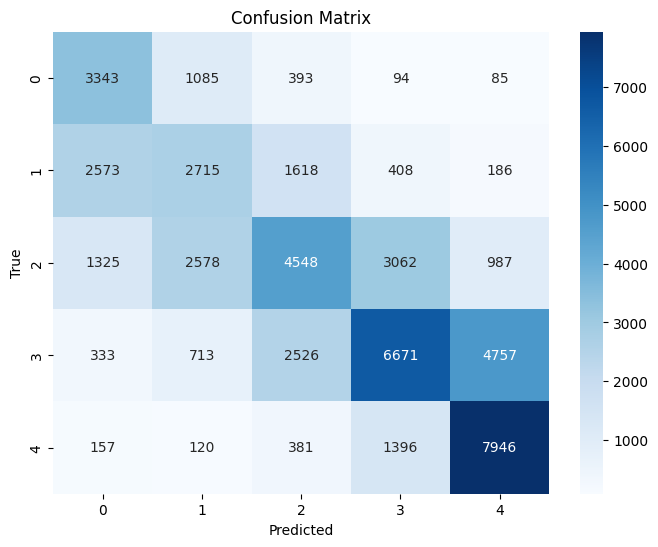

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [16]:
model.save("lstm_review_classifier")

# Save tokenizer and label encoder
import pickle

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

joblib.dump(label_encoder, "label_encoder.pkl")

INFO:tensorflow:Assets written to: lstm_review_classifier\assets


INFO:tensorflow:Assets written to: lstm_review_classifier\assets


['label_encoder.pkl']